In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pahdehrek/names4makemore/names.txt


In [2]:
words = open('/kaggle/input/datasets/pahdehrek/names4makemore/names.txt','r').read().splitlines()
print(words[:5],f"{len(words)=}")

['emma', 'olivia', 'ava', 'isabella', 'sophia'] len(words)=32033


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {x:i+1 for i,x in enumerate(chars)}
stoi['.'] = 0
itos = {i:x for x,i in stoi.items()}

In [4]:
block_size = 3

# def build_dataset(words):
X,Y = [],[]
for w in words:

    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '>>' , itos[ix])
        context = context[1:] + [ix] #crop&append    

X = torch.tensor(X)
Y = torch.tensor(Y)

In [5]:
C = torch.randn((27,2))

In [6]:
emb = C[X]
print(emb.shape)

torch.Size([228146, 3, 2])


In [7]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [8]:
# seq = torch.unbind(emb,axis=1)

In [9]:
# torch.cat(seq,axis =1).shape

In [10]:
# emb.view(emb.shape[0],6).shape

In [11]:
# h = torch.tanh((emb.view(emb.shape[0],6) @ W1) + b1) 
#checked, the bias broadcasting is correct!! yay

In [12]:
# h

In [13]:
# W2 = torch.randn((100,27))
# b2 = torch.randn(27)

In [14]:
# logits = h @ W2 + b2
# logits.shape

In [15]:
# counts = logits.exp()
# probs = counts/counts.sum(1,keepdim=True)
# probs[0].sum()

In [16]:
#vvvvvvvvvvvvvvv ok so now all together vvvvvvvvvvvvvvvv

In [17]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # build_dataset.to(device)
# inputs, labels = inputs.to(device), labels.to(device)

In [18]:
def build_dataset(words):
    X,Y = [],[]
    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)

    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [19]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [20]:
g = torch.Generator().manual_seed(293847) #reproducibility?
C = torch.randn((27,20), generator = g)
W1 = torch.randn((60,300), generator = g)
b1 = torch.randn(300, generator = g)
W2 = torch.randn((300,27), generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad = True

In [21]:
sum(p.nelement() for p in parameters)

26967

In [22]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre


In [23]:
lri = []
lossi = []
stepi=[]


In [24]:
#outputsize = embedding size * block size
output_sz = len(C[0]) * block_size

lri = []
lossi = []
stepi=[]


for i in range(500000):

    #minibatch contruct
    ix = torch.randint(0,Xtr.shape[0],size=(200,))
    
    emb = C[Xtr[ix]] #getting only 32 rows ^^^ of X (32,3,2)
    h = torch.tanh(emb.view(-1,output_sz) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts/counts.sum(axis=1,keepdim=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    lr = 10**-4
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())

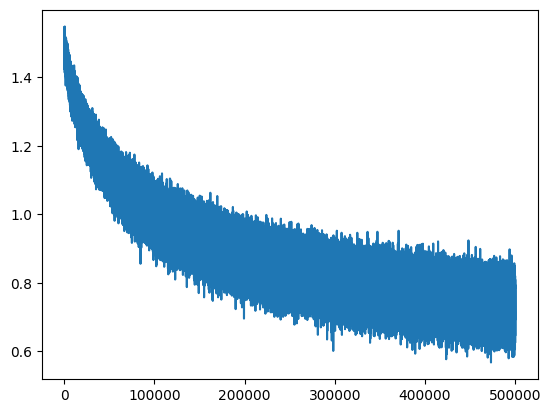

In [25]:
plt.plot(stepi, lossi)
# plt.plot(range(1,10),range(1,10))

In [26]:
emb = C[Xtr] 
h = torch.tanh(emb.view(-1,output_sz) @ W1 + b1)
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts/counts.sum(axis=1,keepdim=True)
# loss = -prob[torch.arange(32),Y].log().mean()
loss = F.cross_entropy(logits, Ytr)
loss

tensor(5.4490, grad_fn=<NllLossBackward0>)

In [27]:
emb = C[Xdev] 
h = torch.tanh(emb.view(-1,output_sz) @ W1 + b1)
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts/counts.sum(axis=1,keepdim=True)
# loss = -prob[torch.arange(32),Y].log().mean()
loss = F.cross_entropy(logits, Ydev)
loss

tensor(5.5041, grad_fn=<NllLossBackward0>)

In [28]:
# plt.figure(figsize=(8,8))
# plt.scatter(C[:,0].data, C[:,1].data , s = 200)
# for i in range(C.shape[0]):
#     plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color = 'white')
#     plt.grid('minor')

In [29]:
g = torch.Generator().manual_seed(2147483647+1)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

iha.
kesryy.
haine.
jane.
bari.
kambiulao.
renalicylyn.
yattyn.
bres.
zermin.
roulyaroen.
matbeson.
jern.
zaiena.
maira.
saniyiannanil.
kin.
harnsatboumcylynn.
kin.
nayah.
